In [26]:
import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torchvision import transforms
from tqdm import tqdm
import matplotlib.pyplot as plt
from transformers import CLIPTokenizer, CLIPTextModel

from noise_schedule import NoiseSchedule
from u_net import UNet
from flower_dataset import FlowerDataset

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
image_size = 64
batch_size = 16
epochs = 200
timesteps = 1000
lr = 2e-4

In [27]:
image_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2 - 1)
])

clip_tokenizer = CLIPTokenizer.from_pretrained('openai/clip-vit-base-patch32')
clip_text_model = CLIPTextModel.from_pretrained('openai/clip-vit-base-patch32').to(device)
clip_text_model.eval()
for param in clip_text_model.parameters():
    param.requires_grad = False

c:\Users\lolan\Desktop\projects\text-to-image-generator\venv\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\lolan\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 196/196 [00:00<00:00, 35197.96it/s]
[transfor

In [15]:
dataset = FlowerDataset(
    annotations='../captions.csv',
    img_dir='../images/train',
    image_transform=image_transform,
    caption_transform=None, # for now
)

In [16]:
dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)

In [21]:
schedule = NoiseSchedule(timesteps=timesteps, device=device)
model = UNet(in_channels=3, base_channels=64).to(device)
model.load_state_dict(torch.load('unet_checkpoint.pt'))
optimizer = AdamW(model.parameters(), lr=lr)
loss_fn = torch.nn.MSELoss()

In [23]:
@torch.no_grad()
def sample(model, schedule, image_size=64, batch_size=4, channels=3, device='cpu'):
    model.eval()

    x = torch.randn(batch_size, channels, image_size, image_size, device=device)
    for t_step in reversed(range(schedule.timesteps)):
        t = torch.full((batch_size,), t_step, device=device, dtype=torch.long)
        predicted_noise = model(x, t)

        alpha = schedule.alphas[t_step]
        alpha_bar = schedule.alphas.cumprod[t_step]
        beta = schedule.betas[t_step]

        if t_step > 0:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x)

        x = (1/torch.sqrt(alpha)) * (
            x - ((1-alpha) / torch.sqrt(1 - alpha_bar)) * predicted_noise
        ) + torch.sqrt(beta) * noise

        model.train()
        return x

Epoch 1/400: 100%|██████████| 172/172 [00:08<00:00, 21.37it/s, loss=0.0257] 


Epoch 1 average loss is 0.0345


Epoch 2/400: 100%|██████████| 172/172 [00:07<00:00, 21.81it/s, loss=0.0154] 


Epoch 2 average loss is 0.0315


Epoch 3/400: 100%|██████████| 172/172 [00:07<00:00, 21.74it/s, loss=0.0322] 


...

Epoch 8/400: 100%|██████████| 172/172 [00:08<00:00, 21.27it/s, loss=0.0202] 


Epoch 8 average loss is 0.0337


Epoch 9/400: 100%|██████████| 172/172 [00:07<00:00, 21.82it/s, loss=0.0265] 


Epoch 9 average loss is 0.0327


Epoch 10/400: 100%|██████████| 172/172 [00:07<00:00, 21.56it/s, loss=0.0445] 


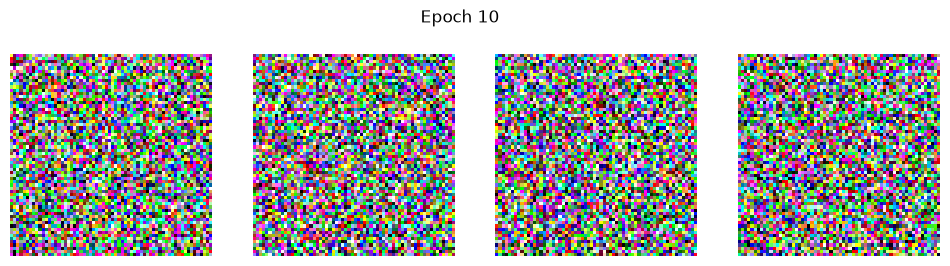

Epoch 10 average loss is 0.0326


Epoch 11/400: 100%|██████████| 172/172 [00:08<00:00, 20.94it/s, loss=0.0109] 


Epoch 11 average loss is 0.0326


Epoch 12/400: 100%|██████████| 172/172 [00:08<00:00, 21.47it/s, loss=0.00928]


Epoch 12 average loss is 0.0321


...

Epoch 18/400: 100%|██████████| 172/172 [00:07<00:00, 22.36it/s, loss=0.0236] 


Epoch 18 average loss is 0.0320


Epoch 19/400: 100%|██████████| 172/172 [00:07<00:00, 22.52it/s, loss=0.0341] 


Epoch 19 average loss is 0.0311


Epoch 20/400: 100%|██████████| 172/172 [00:07<00:00, 22.85it/s, loss=0.00871]


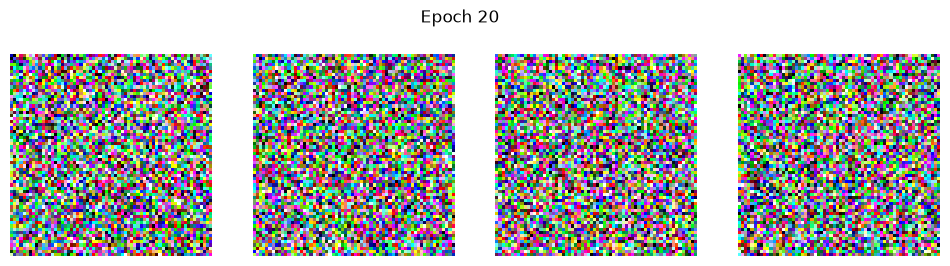

Epoch 20 average loss is 0.0317


Epoch 21/400: 100%|██████████| 172/172 [00:07<00:00, 22.67it/s, loss=0.0271] 


Epoch 21 average loss is 0.0303


Epoch 22/400: 100%|██████████| 172/172 [00:07<00:00, 22.95it/s, loss=0.0588] 


Epoch 22 average loss is 0.0308


...

Epoch 28/400: 100%|██████████| 172/172 [00:07<00:00, 22.81it/s, loss=0.00931]


Epoch 28 average loss is 0.0336


Epoch 29/400: 100%|██████████| 172/172 [00:07<00:00, 22.82it/s, loss=0.0266] 


Epoch 29 average loss is 0.0321


Epoch 30/400: 100%|██████████| 172/172 [00:07<00:00, 22.83it/s, loss=0.0595] 


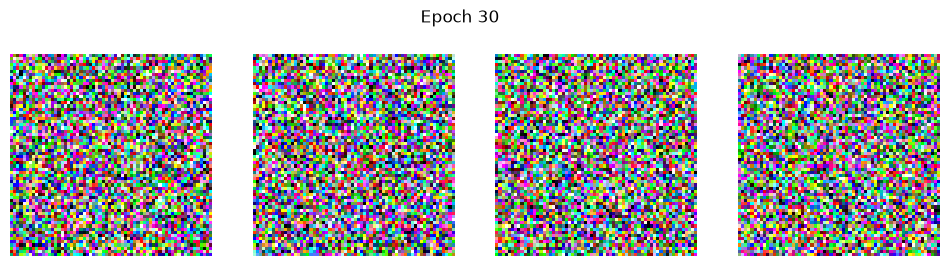

Epoch 30 average loss is 0.0325


Epoch 31/400: 100%|██████████| 172/172 [00:07<00:00, 23.10it/s, loss=0.0131] 


Epoch 31 average loss is 0.0308


Epoch 32/400: 100%|██████████| 172/172 [00:07<00:00, 23.16it/s, loss=0.00961]


Epoch 32 average loss is 0.0314


...

Epoch 38/400: 100%|██████████| 172/172 [00:07<00:00, 23.21it/s, loss=0.0094] 


Epoch 38 average loss is 0.0299


Epoch 39/400: 100%|██████████| 172/172 [00:07<00:00, 23.17it/s, loss=0.0118] 


Epoch 39 average loss is 0.0309


Epoch 40/400: 100%|██████████| 172/172 [00:07<00:00, 23.16it/s, loss=0.0529] 


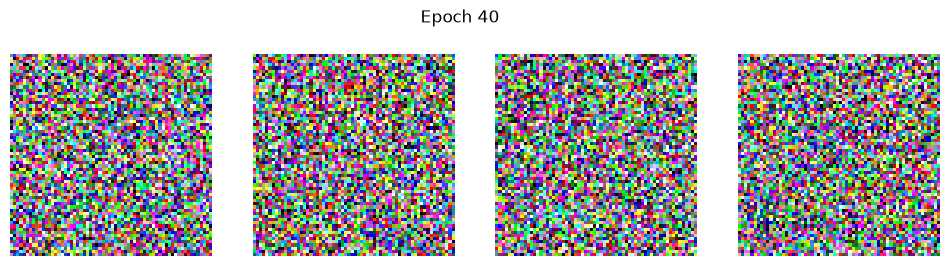

Epoch 40 average loss is 0.0322


Epoch 41/400: 100%|██████████| 172/172 [00:07<00:00, 23.01it/s, loss=0.0244] 


Epoch 41 average loss is 0.0329


Epoch 42/400: 100%|██████████| 172/172 [00:07<00:00, 22.73it/s, loss=0.0304] 


Epoch 42 average loss is 0.0339


...

Epoch 48/400: 100%|██████████| 172/172 [00:07<00:00, 22.37it/s, loss=0.0282] 


Epoch 48 average loss is 0.0326


Epoch 49/400: 100%|██████████| 172/172 [00:07<00:00, 22.33it/s, loss=0.0509] 


Epoch 49 average loss is 0.0314


Epoch 50/400: 100%|██████████| 172/172 [00:07<00:00, 21.62it/s, loss=0.0439] 


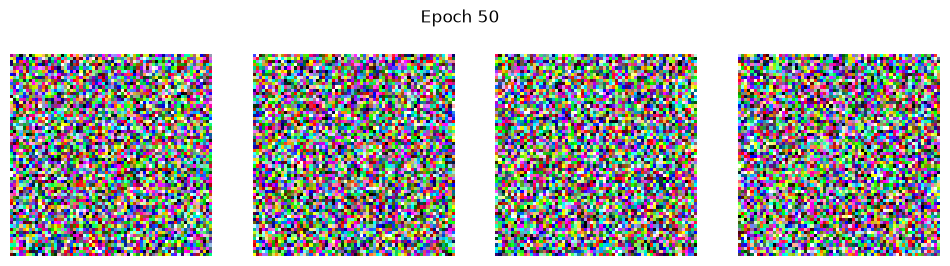

Epoch 50 average loss is 0.0314


Epoch 51/400: 100%|██████████| 172/172 [00:07<00:00, 22.42it/s, loss=0.00933]


Epoch 51 average loss is 0.0310


Epoch 52/400: 100%|██████████| 172/172 [00:07<00:00, 22.71it/s, loss=0.0381] 


Epoch 52 average loss is 0.0358


...

Epoch 58/400: 100%|██████████| 172/172 [00:08<00:00, 21.32it/s, loss=0.0105] 


Epoch 58 average loss is 0.0334


Epoch 59/400: 100%|██████████| 172/172 [00:07<00:00, 22.03it/s, loss=0.0482] 


Epoch 59 average loss is 0.0326


Epoch 60/400: 100%|██████████| 172/172 [00:07<00:00, 22.57it/s, loss=0.0599] 


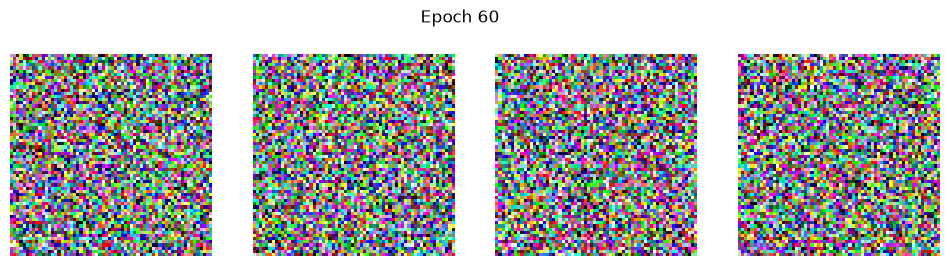

Epoch 60 average loss is 0.0318


Epoch 61/400: 100%|██████████| 172/172 [00:07<00:00, 22.60it/s, loss=0.0215] 


Epoch 61 average loss is 0.0303


Epoch 62/400: 100%|██████████| 172/172 [00:07<00:00, 22.49it/s, loss=0.029]  


Epoch 62 average loss is 0.0307


...

Epoch 68/400: 100%|██████████| 172/172 [00:07<00:00, 22.58it/s, loss=0.0511] 


Epoch 68 average loss is 0.0315


Epoch 69/400: 100%|██████████| 172/172 [00:07<00:00, 22.65it/s, loss=0.0745] 


Epoch 69 average loss is 0.0323


Epoch 70/400: 100%|██████████| 172/172 [00:07<00:00, 22.34it/s, loss=0.00542]


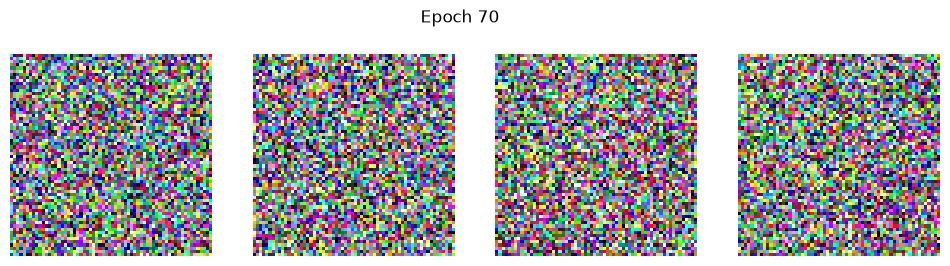

Epoch 70 average loss is 0.0303


Epoch 71/400: 100%|██████████| 172/172 [00:07<00:00, 22.56it/s, loss=0.0531] 


Epoch 71 average loss is 0.0301


Epoch 72/400: 100%|██████████| 172/172 [00:07<00:00, 22.63it/s, loss=0.0468] 


Epoch 72 average loss is 0.0335


...

Epoch 78/400: 100%|██████████| 172/172 [00:07<00:00, 22.59it/s, loss=0.0346] 


Epoch 78 average loss is 0.0314


Epoch 79/400: 100%|██████████| 172/172 [00:07<00:00, 22.39it/s, loss=0.0452] 


Epoch 79 average loss is 0.0319


Epoch 80/400: 100%|██████████| 172/172 [00:07<00:00, 22.68it/s, loss=0.0391] 


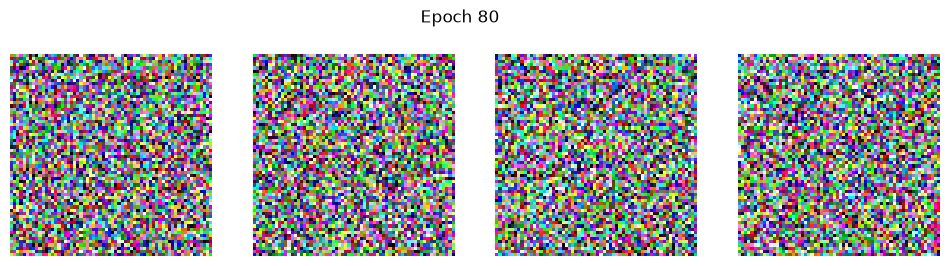

Epoch 80 average loss is 0.0337


Epoch 81/400: 100%|██████████| 172/172 [00:07<00:00, 22.43it/s, loss=0.0183] 


Epoch 81 average loss is 0.0318


Epoch 82/400: 100%|██████████| 172/172 [00:07<00:00, 22.22it/s, loss=0.0221] 


Epoch 82 average loss is 0.0323


...

Epoch 88/400: 100%|██████████| 172/172 [00:07<00:00, 22.53it/s, loss=0.0533] 


Epoch 88 average loss is 0.0321


Epoch 89/400: 100%|██████████| 172/172 [00:07<00:00, 22.01it/s, loss=0.031]  


Epoch 89 average loss is 0.0315


Epoch 90/400: 100%|██████████| 172/172 [00:07<00:00, 22.38it/s, loss=0.0416] 


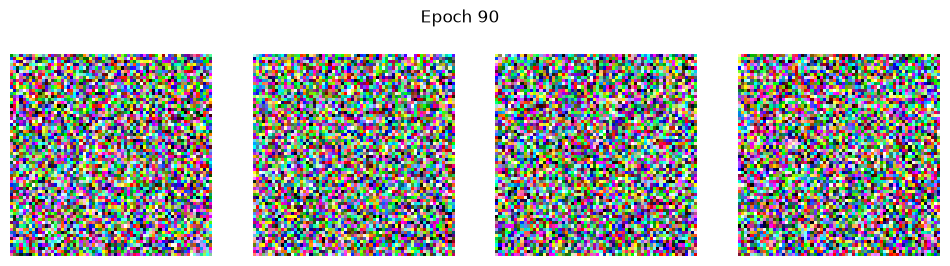

Epoch 90 average loss is 0.0318


Epoch 91/400: 100%|██████████| 172/172 [00:07<00:00, 22.35it/s, loss=0.0768] 


Epoch 91 average loss is 0.0308


Epoch 92/400: 100%|██████████| 172/172 [00:07<00:00, 22.54it/s, loss=0.097]  


Epoch 92 average loss is 0.0305


...

Epoch 98/400: 100%|██████████| 172/172 [00:07<00:00, 22.47it/s, loss=0.0579] 


Epoch 98 average loss is 0.0324


Epoch 99/400: 100%|██████████| 172/172 [00:07<00:00, 22.37it/s, loss=0.0452] 


Epoch 99 average loss is 0.0333


Epoch 100/400: 100%|██████████| 172/172 [00:07<00:00, 22.61it/s, loss=0.0494] 


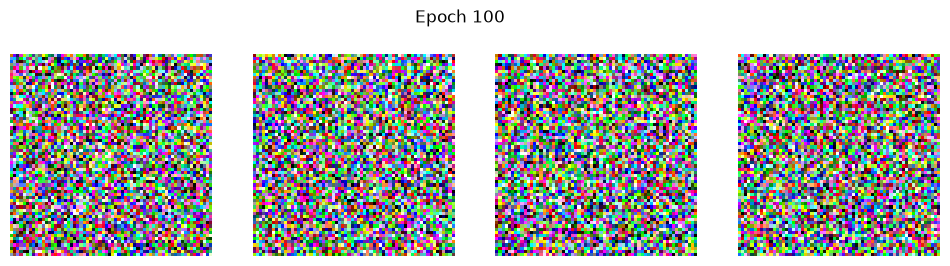

Epoch 100 average loss is 0.0297


Epoch 101/400: 100%|██████████| 172/172 [00:07<00:00, 22.65it/s, loss=0.0157] 


Epoch 101 average loss is 0.0320


Epoch 102/400: 100%|██████████| 172/172 [00:07<00:00, 22.52it/s, loss=0.0298] 


Epoch 102 average loss is 0.0310


...

Epoch 108/400: 100%|██████████| 172/172 [00:07<00:00, 22.50it/s, loss=0.0351] 


Epoch 108 average loss is 0.0322


Epoch 109/400: 100%|██████████| 172/172 [00:07<00:00, 22.57it/s, loss=0.0374] 


Epoch 109 average loss is 0.0299


Epoch 110/400: 100%|██████████| 172/172 [00:07<00:00, 22.56it/s, loss=0.0353] 


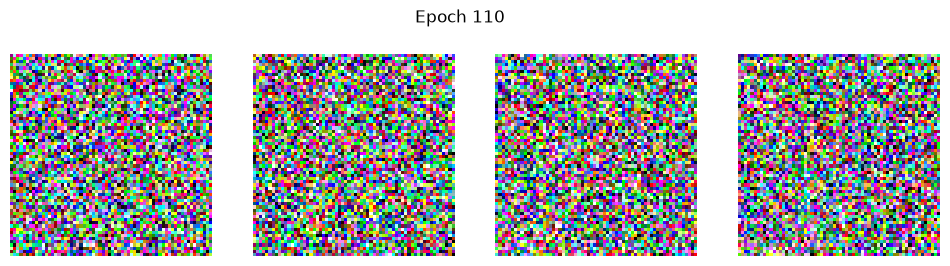

Epoch 110 average loss is 0.0300


Epoch 111/400: 100%|██████████| 172/172 [00:07<00:00, 22.41it/s, loss=0.0411] 


Epoch 111 average loss is 0.0336


Epoch 112/400: 100%|██████████| 172/172 [00:07<00:00, 22.59it/s, loss=0.0489] 


Epoch 112 average loss is 0.0318


...

Epoch 118/400: 100%|██████████| 172/172 [00:07<00:00, 22.56it/s, loss=0.0268] 


Epoch 118 average loss is 0.0316


Epoch 119/400: 100%|██████████| 172/172 [00:07<00:00, 22.35it/s, loss=0.057]  


Epoch 119 average loss is 0.0295


Epoch 120/400: 100%|██████████| 172/172 [00:07<00:00, 22.38it/s, loss=0.013]  


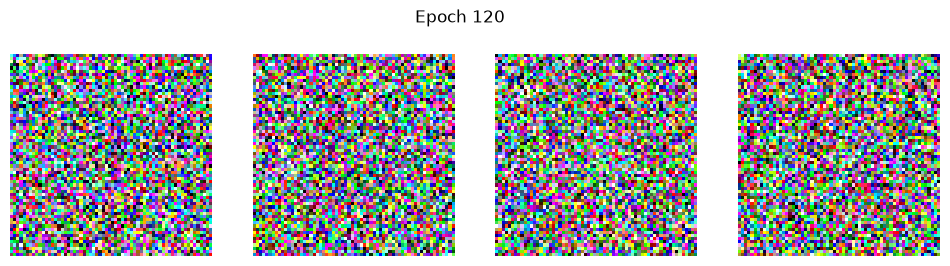

Epoch 120 average loss is 0.0299


Epoch 121/400: 100%|██████████| 172/172 [00:07<00:00, 22.38it/s, loss=0.0532] 


Epoch 121 average loss is 0.0315


Epoch 122/400: 100%|██████████| 172/172 [00:07<00:00, 22.46it/s, loss=0.0586] 


Epoch 122 average loss is 0.0305


...

Epoch 128/400: 100%|██████████| 172/172 [00:07<00:00, 21.98it/s, loss=0.0255] 


Epoch 128 average loss is 0.0291


Epoch 129/400: 100%|██████████| 172/172 [00:07<00:00, 22.55it/s, loss=0.0167] 


Epoch 129 average loss is 0.0285


Epoch 130/400: 100%|██████████| 172/172 [00:07<00:00, 22.58it/s, loss=0.0151] 


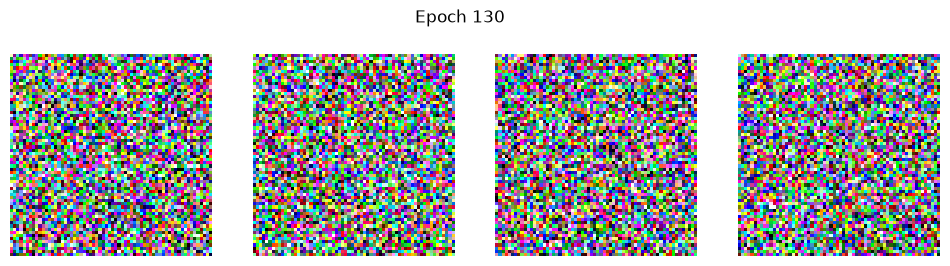

Epoch 130 average loss is 0.0309


Epoch 131/400: 100%|██████████| 172/172 [00:07<00:00, 22.34it/s, loss=0.0117] 


Epoch 131 average loss is 0.0304


Epoch 132/400: 100%|██████████| 172/172 [00:07<00:00, 22.50it/s, loss=0.0473] 


Epoch 132 average loss is 0.0296


...

Epoch 138/400: 100%|██████████| 172/172 [00:07<00:00, 21.94it/s, loss=0.0357] 


Epoch 138 average loss is 0.0295


Epoch 139/400: 100%|██████████| 172/172 [00:07<00:00, 21.66it/s, loss=0.00979]


Epoch 139 average loss is 0.0332


Epoch 140/400: 100%|██████████| 172/172 [00:07<00:00, 22.00it/s, loss=0.0252]


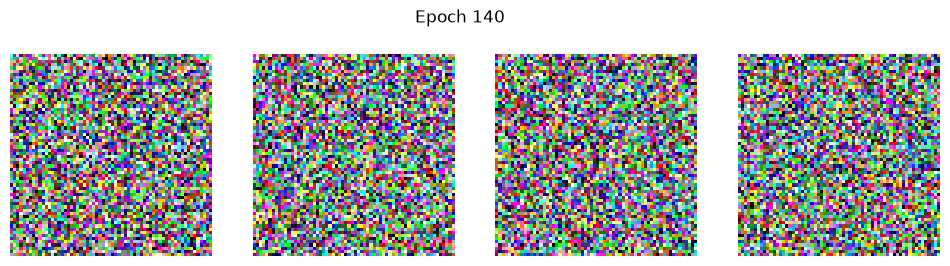

Epoch 140 average loss is 0.0304


Epoch 141/400: 100%|██████████| 172/172 [00:07<00:00, 22.24it/s, loss=0.0121] 


Epoch 141 average loss is 0.0309


Epoch 142/400: 100%|██████████| 172/172 [00:07<00:00, 22.18it/s, loss=0.0434] 


Epoch 142 average loss is 0.0319


...

Epoch 148/400: 100%|██████████| 172/172 [00:07<00:00, 22.17it/s, loss=0.022]  


Epoch 148 average loss is 0.0303


Epoch 149/400: 100%|██████████| 172/172 [00:07<00:00, 22.38it/s, loss=0.0448] 


Epoch 149 average loss is 0.0308


Epoch 150/400: 100%|██████████| 172/172 [00:07<00:00, 22.35it/s, loss=0.0118] 


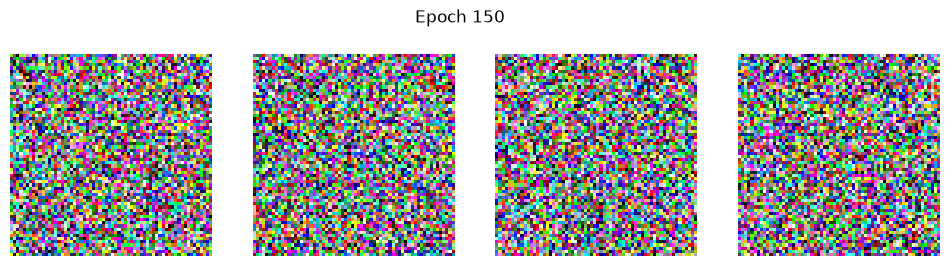

Epoch 150 average loss is 0.0321


Epoch 151/400: 100%|██████████| 172/172 [00:07<00:00, 21.76it/s, loss=0.00667]


Epoch 151 average loss is 0.0310


Epoch 152/400: 100%|██████████| 172/172 [00:07<00:00, 21.52it/s, loss=0.103]  


Epoch 152 average loss is 0.0344


...

Epoch 158/400: 100%|██████████| 172/172 [00:07<00:00, 22.40it/s, loss=0.0273] 


Epoch 158 average loss is 0.0337


Epoch 159/400: 100%|██████████| 172/172 [00:07<00:00, 21.81it/s, loss=0.0123] 


Epoch 159 average loss is 0.0302


Epoch 160/400: 100%|██████████| 172/172 [00:07<00:00, 22.33it/s, loss=0.00672]


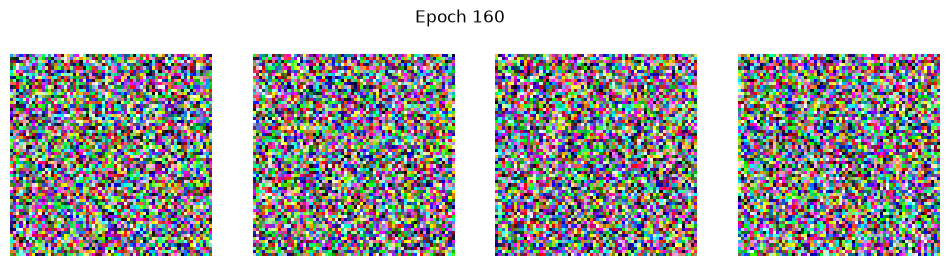

Epoch 160 average loss is 0.0308


Epoch 161/400: 100%|██████████| 172/172 [00:07<00:00, 22.12it/s, loss=0.0791] 


Epoch 161 average loss is 0.0315


Epoch 162/400: 100%|██████████| 172/172 [00:07<00:00, 21.75it/s, loss=0.0383] 


Epoch 162 average loss is 0.0297


...

Epoch 168/400: 100%|██████████| 172/172 [00:07<00:00, 22.29it/s, loss=0.0369] 


Epoch 168 average loss is 0.0328


Epoch 169/400: 100%|██████████| 172/172 [00:07<00:00, 22.60it/s, loss=0.0112]


Epoch 169 average loss is 0.0308


Epoch 170/400: 100%|██████████| 172/172 [00:07<00:00, 22.54it/s, loss=0.0642] 


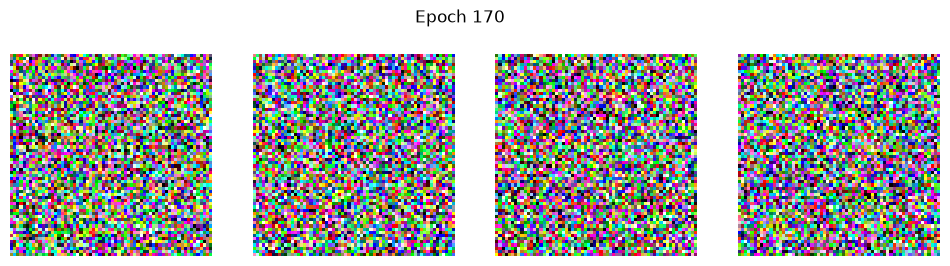

Epoch 170 average loss is 0.0296


Epoch 171/400: 100%|██████████| 172/172 [00:07<00:00, 22.40it/s, loss=0.0313] 


Epoch 171 average loss is 0.0305


Epoch 172/400: 100%|██████████| 172/172 [00:07<00:00, 22.65it/s, loss=0.0285] 


Epoch 172 average loss is 0.0300


...

Epoch 178/400: 100%|██████████| 172/172 [00:07<00:00, 22.62it/s, loss=0.00679]


Epoch 178 average loss is 0.0290


Epoch 179/400: 100%|██████████| 172/172 [00:07<00:00, 22.37it/s, loss=0.0169] 


Epoch 179 average loss is 0.0308


Epoch 180/400: 100%|██████████| 172/172 [00:07<00:00, 22.59it/s, loss=0.0313] 


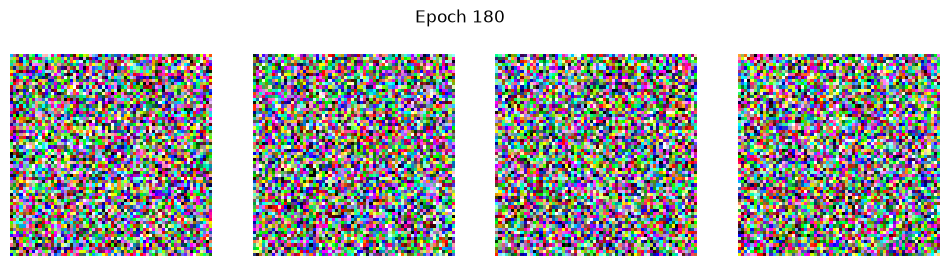

Epoch 180 average loss is 0.0297


Epoch 181/400: 100%|██████████| 172/172 [00:07<00:00, 22.57it/s, loss=0.0338] 


Epoch 181 average loss is 0.0309


Epoch 182/400: 100%|██████████| 172/172 [00:07<00:00, 22.06it/s, loss=0.0219] 


Epoch 182 average loss is 0.0288


...

Epoch 188/400: 100%|██████████| 172/172 [00:07<00:00, 22.04it/s, loss=0.0403] 


Epoch 188 average loss is 0.0315


Epoch 189/400: 100%|██████████| 172/172 [00:07<00:00, 22.54it/s, loss=0.0238] 


Epoch 189 average loss is 0.0328


Epoch 190/400: 100%|██████████| 172/172 [00:07<00:00, 22.10it/s, loss=0.0435] 


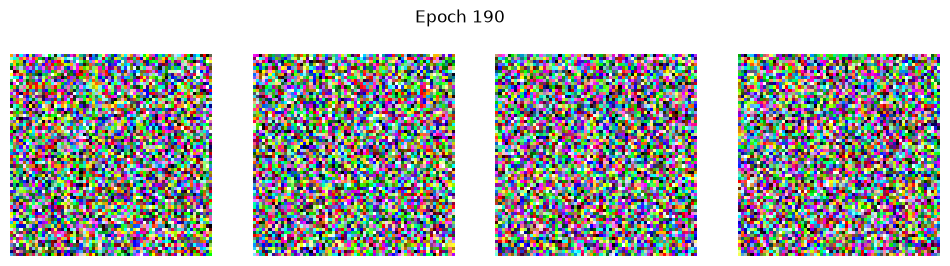

Epoch 190 average loss is 0.0327


Epoch 191/400: 100%|██████████| 172/172 [00:07<00:00, 22.28it/s, loss=0.018] 


Epoch 191 average loss is 0.0311


Epoch 192/400: 100%|██████████| 172/172 [00:07<00:00, 22.48it/s, loss=0.0298] 


Epoch 192 average loss is 0.0316


...

Epoch 198/400: 100%|██████████| 172/172 [00:07<00:00, 22.14it/s, loss=0.0213] 


Epoch 198 average loss is 0.0310


Epoch 199/400: 100%|██████████| 172/172 [00:07<00:00, 22.25it/s, loss=0.0148] 


Epoch 199 average loss is 0.0290


Epoch 200/400: 100%|██████████| 172/172 [00:07<00:00, 22.46it/s, loss=0.0331] 


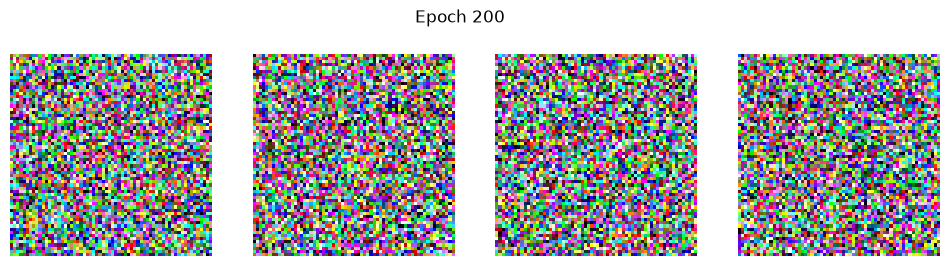

Epoch 200 average loss is 0.0311


Epoch 201/400: 100%|██████████| 172/172 [00:07<00:00, 22.58it/s, loss=0.0686] 


Epoch 201 average loss is 0.0314


Epoch 202/400: 100%|██████████| 172/172 [00:07<00:00, 22.31it/s, loss=0.0393] 


Epoch 202 average loss is 0.0312


...

Epoch 208/400: 100%|██████████| 172/172 [00:07<00:00, 22.31it/s, loss=0.0131] 


Epoch 208 average loss is 0.0302


Epoch 209/400: 100%|██████████| 172/172 [00:07<00:00, 22.60it/s, loss=0.0326] 


Epoch 209 average loss is 0.0314


Epoch 210/400: 100%|██████████| 172/172 [00:07<00:00, 22.59it/s, loss=0.0214] 


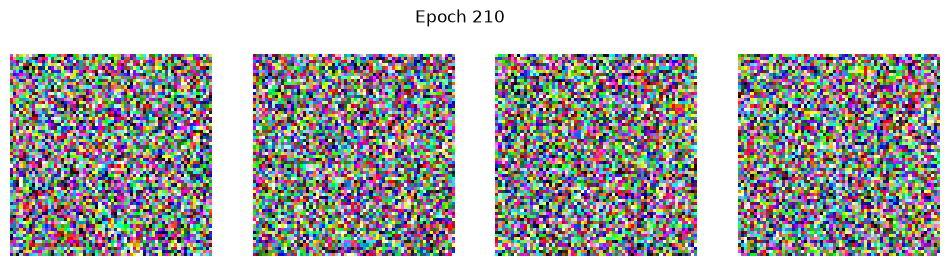

Epoch 210 average loss is 0.0308


Epoch 211/400: 100%|██████████| 172/172 [00:07<00:00, 22.38it/s, loss=0.0231] 


Epoch 211 average loss is 0.0304


Epoch 212/400: 100%|██████████| 172/172 [00:07<00:00, 22.58it/s, loss=0.0504] 


Epoch 212 average loss is 0.0292


...

Epoch 218/400: 100%|██████████| 172/172 [00:07<00:00, 22.56it/s, loss=0.00451]


Epoch 218 average loss is 0.0310


Epoch 219/400: 100%|██████████| 172/172 [00:07<00:00, 22.47it/s, loss=0.016] 


Epoch 219 average loss is 0.0328


Epoch 220/400: 100%|██████████| 172/172 [00:07<00:00, 22.47it/s, loss=0.0385] 


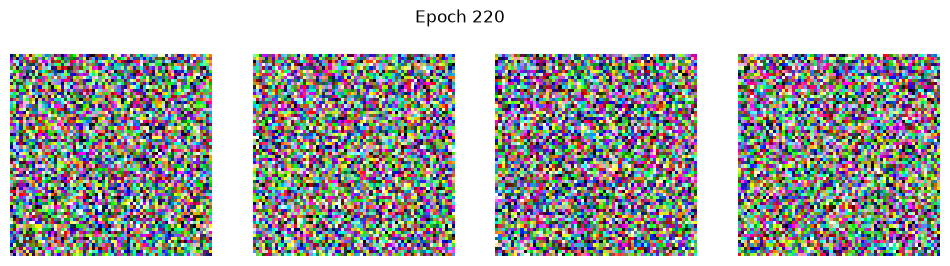

Epoch 220 average loss is 0.0310


Epoch 221/400: 100%|██████████| 172/172 [00:07<00:00, 22.31it/s, loss=0.0248] 


Epoch 221 average loss is 0.0307


Epoch 222/400: 100%|██████████| 172/172 [00:07<00:00, 22.35it/s, loss=0.0124] 


Epoch 222 average loss is 0.0307


...

Epoch 228/400: 100%|██████████| 172/172 [00:07<00:00, 22.40it/s, loss=0.0287] 


Epoch 228 average loss is 0.0296


Epoch 229/400: 100%|██████████| 172/172 [00:07<00:00, 22.23it/s, loss=0.0523] 


Epoch 229 average loss is 0.0325


Epoch 230/400: 100%|██████████| 172/172 [00:07<00:00, 22.65it/s, loss=0.0176] 


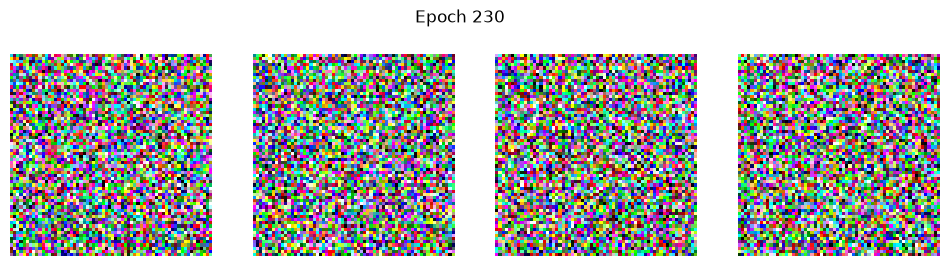

Epoch 230 average loss is 0.0326


Epoch 231/400: 100%|██████████| 172/172 [00:07<00:00, 22.43it/s, loss=0.0505] 


Epoch 231 average loss is 0.0309


Epoch 232/400: 100%|██████████| 172/172 [00:07<00:00, 22.65it/s, loss=0.0141] 


Epoch 232 average loss is 0.0328


...

Epoch 238/400: 100%|██████████| 172/172 [00:07<00:00, 22.54it/s, loss=0.0224] 


Epoch 238 average loss is 0.0306


Epoch 239/400: 100%|██████████| 172/172 [00:07<00:00, 22.66it/s, loss=0.0208]


Epoch 239 average loss is 0.0322


Epoch 240/400: 100%|██████████| 172/172 [00:07<00:00, 22.04it/s, loss=0.0103] 


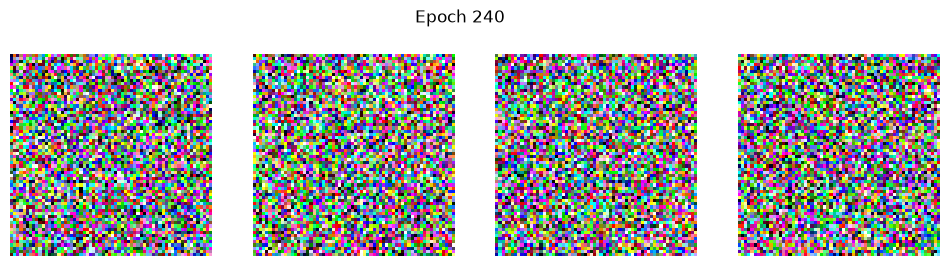

Epoch 240 average loss is 0.0297


Epoch 241/400: 100%|██████████| 172/172 [00:07<00:00, 22.36it/s, loss=0.00983]


Epoch 241 average loss is 0.0316


Epoch 242/400: 100%|██████████| 172/172 [00:07<00:00, 22.24it/s, loss=0.0408] 


Epoch 242 average loss is 0.0304


...

Epoch 248/400: 100%|██████████| 172/172 [00:07<00:00, 22.25it/s, loss=0.00998]


Epoch 248 average loss is 0.0324


Epoch 249/400: 100%|██████████| 172/172 [00:07<00:00, 22.47it/s, loss=0.0122] 


Epoch 249 average loss is 0.0301


Epoch 250/400: 100%|██████████| 172/172 [00:07<00:00, 22.50it/s, loss=0.0215] 


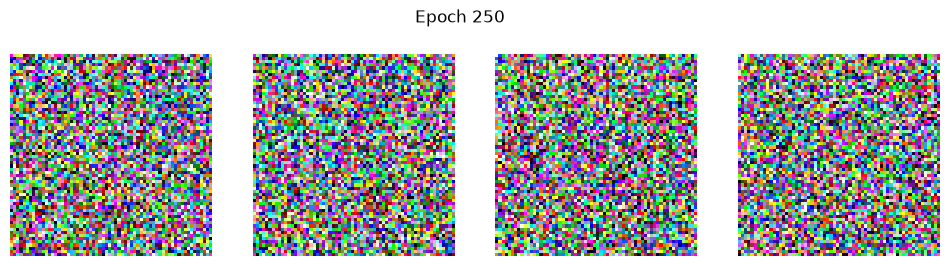

Epoch 250 average loss is 0.0315


Epoch 251/400: 100%|██████████| 172/172 [00:07<00:00, 22.01it/s, loss=0.0199] 


Epoch 251 average loss is 0.0307


Epoch 252/400: 100%|██████████| 172/172 [00:07<00:00, 22.49it/s, loss=0.0227] 


Epoch 252 average loss is 0.0314


...

Epoch 258/400: 100%|██████████| 172/172 [00:07<00:00, 22.50it/s, loss=0.0395] 


Epoch 258 average loss is 0.0314


Epoch 259/400: 100%|██████████| 172/172 [00:07<00:00, 22.49it/s, loss=0.0748] 


Epoch 259 average loss is 0.0295


Epoch 260/400: 100%|██████████| 172/172 [00:07<00:00, 21.89it/s, loss=0.0256] 


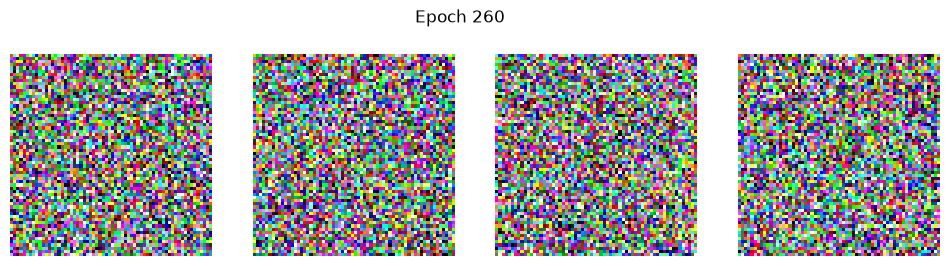

Epoch 260 average loss is 0.0330


Epoch 261/400: 100%|██████████| 172/172 [00:07<00:00, 22.41it/s, loss=0.0539] 


Epoch 261 average loss is 0.0314


Epoch 262/400: 100%|██████████| 172/172 [00:07<00:00, 22.32it/s, loss=0.0887]


Epoch 262 average loss is 0.0304


...

Epoch 268/400: 100%|██████████| 172/172 [00:07<00:00, 21.98it/s, loss=0.00744]


Epoch 268 average loss is 0.0307


Epoch 269/400: 100%|██████████| 172/172 [00:07<00:00, 22.35it/s, loss=0.00421]


Epoch 269 average loss is 0.0321


Epoch 270/400: 100%|██████████| 172/172 [00:07<00:00, 22.39it/s, loss=0.0453] 


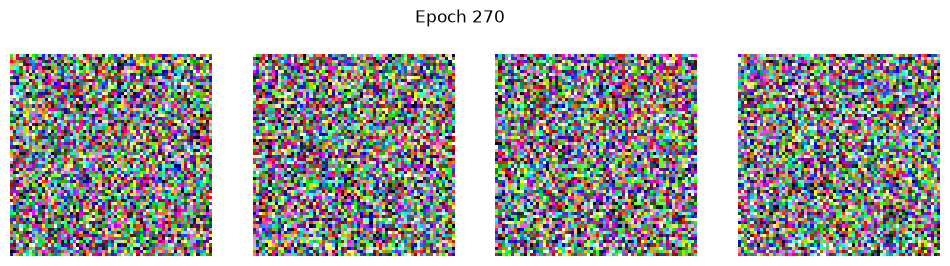

Epoch 270 average loss is 0.0291


Epoch 271/400: 100%|██████████| 172/172 [00:07<00:00, 22.51it/s, loss=0.0455] 


Epoch 271 average loss is 0.0311


Epoch 272/400: 100%|██████████| 172/172 [00:07<00:00, 22.67it/s, loss=0.00749]


Epoch 272 average loss is 0.0300


...

Epoch 278/400: 100%|██████████| 172/172 [00:07<00:00, 22.64it/s, loss=0.00439]


Epoch 278 average loss is 0.0305


Epoch 279/400: 100%|██████████| 172/172 [00:07<00:00, 22.73it/s, loss=0.0246] 


Epoch 279 average loss is 0.0290


Epoch 280/400: 100%|██████████| 172/172 [00:07<00:00, 22.42it/s, loss=0.013]  


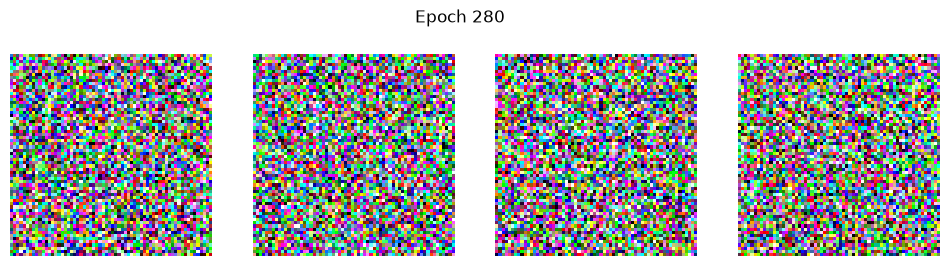

Epoch 280 average loss is 0.0333


Epoch 281/400: 100%|██████████| 172/172 [00:07<00:00, 22.66it/s, loss=0.0478] 


Epoch 281 average loss is 0.0292


Epoch 282/400: 100%|██████████| 172/172 [00:07<00:00, 22.66it/s, loss=0.0893] 


Epoch 282 average loss is 0.0326


...

Epoch 288/400: 100%|██████████| 172/172 [00:07<00:00, 22.49it/s, loss=0.00914]


Epoch 288 average loss is 0.0294


Epoch 289/400: 100%|██████████| 172/172 [00:07<00:00, 22.50it/s, loss=0.0196] 


Epoch 289 average loss is 0.0314


Epoch 290/400: 100%|██████████| 172/172 [00:07<00:00, 22.66it/s, loss=0.0424] 


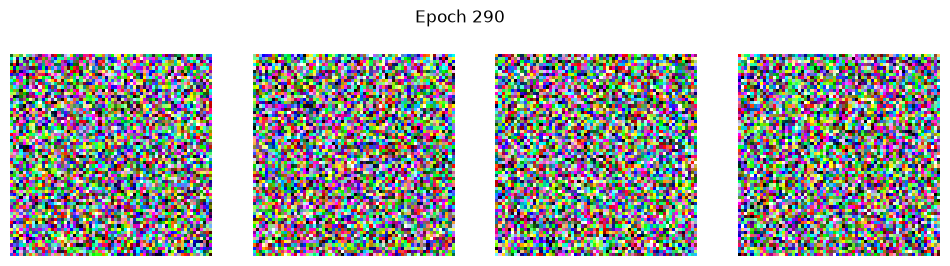

Epoch 290 average loss is 0.0282


Epoch 291/400: 100%|██████████| 172/172 [00:07<00:00, 22.39it/s, loss=0.0195]


Epoch 291 average loss is 0.0314


Epoch 292/400: 100%|██████████| 172/172 [00:07<00:00, 21.95it/s, loss=0.0148] 


Epoch 292 average loss is 0.0314


...

Epoch 298/400: 100%|██████████| 172/172 [00:07<00:00, 22.49it/s, loss=0.0178] 


Epoch 298 average loss is 0.0332


Epoch 299/400: 100%|██████████| 172/172 [00:07<00:00, 22.12it/s, loss=0.0229] 


Epoch 299 average loss is 0.0306


Epoch 300/400: 100%|██████████| 172/172 [00:07<00:00, 22.17it/s, loss=0.0357] 


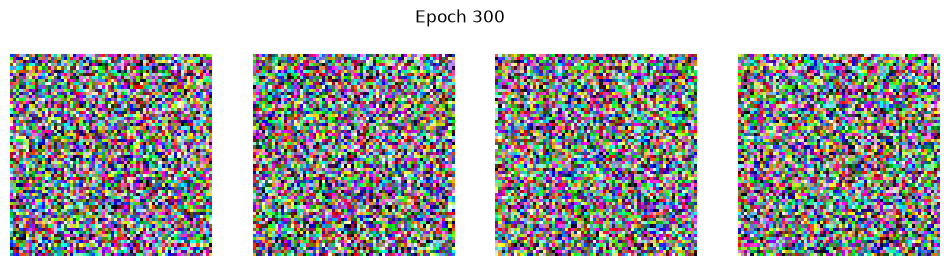

Epoch 300 average loss is 0.0310


Epoch 301/400: 100%|██████████| 172/172 [00:07<00:00, 22.56it/s, loss=0.0435] 


Epoch 301 average loss is 0.0305


Epoch 302/400: 100%|██████████| 172/172 [00:07<00:00, 22.59it/s, loss=0.0134] 


Epoch 302 average loss is 0.0288


...

Epoch 308/400: 100%|██████████| 172/172 [00:07<00:00, 22.50it/s, loss=0.0053] 


Epoch 308 average loss is 0.0297


Epoch 309/400: 100%|██████████| 172/172 [00:07<00:00, 22.48it/s, loss=0.0505] 


Epoch 309 average loss is 0.0300


Epoch 310/400: 100%|██████████| 172/172 [00:07<00:00, 22.59it/s, loss=0.0171] 


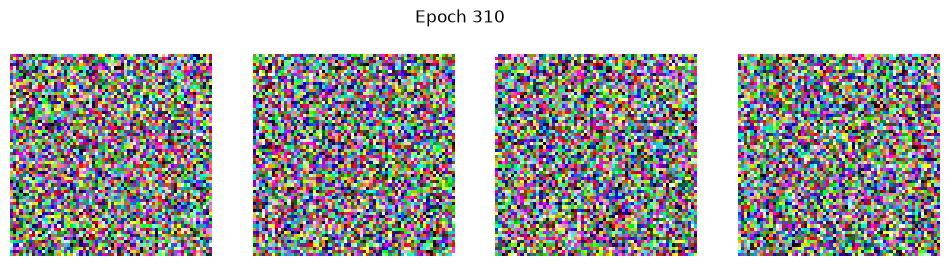

Epoch 310 average loss is 0.0306


Epoch 311/400: 100%|██████████| 172/172 [00:07<00:00, 22.52it/s, loss=0.0308] 


Epoch 311 average loss is 0.0330


Epoch 312/400: 100%|██████████| 172/172 [00:07<00:00, 22.43it/s, loss=0.017]  


Epoch 312 average loss is 0.0307


...

Epoch 318/400: 100%|██████████| 172/172 [00:07<00:00, 22.50it/s, loss=0.0154]


Epoch 318 average loss is 0.0323


Epoch 319/400: 100%|██████████| 172/172 [00:07<00:00, 22.60it/s, loss=0.122]  


Epoch 319 average loss is 0.0329


Epoch 320/400: 100%|██████████| 172/172 [00:07<00:00, 22.38it/s, loss=0.068]  


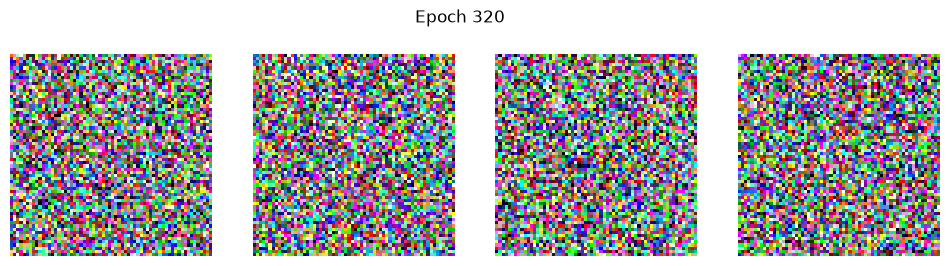

Epoch 320 average loss is 0.0301


Epoch 321/400: 100%|██████████| 172/172 [00:07<00:00, 22.41it/s, loss=0.0189] 


Epoch 321 average loss is 0.0295


Epoch 322/400: 100%|██████████| 172/172 [00:07<00:00, 22.41it/s, loss=0.0216] 


Epoch 322 average loss is 0.0299


...

Epoch 328/400: 100%|██████████| 172/172 [00:07<00:00, 22.49it/s, loss=0.0117] 


Epoch 328 average loss is 0.0321


Epoch 329/400: 100%|██████████| 172/172 [00:07<00:00, 22.15it/s, loss=0.0634] 


Epoch 329 average loss is 0.0328


Epoch 330/400: 100%|██████████| 172/172 [00:07<00:00, 22.32it/s, loss=0.0152] 


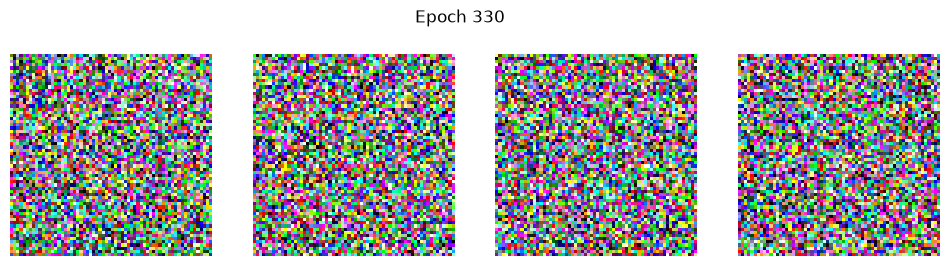

Epoch 330 average loss is 0.0310


Epoch 331/400: 100%|██████████| 172/172 [00:07<00:00, 22.24it/s, loss=0.0273] 


Epoch 331 average loss is 0.0292


Epoch 332/400: 100%|██████████| 172/172 [00:07<00:00, 22.29it/s, loss=0.0182] 


Epoch 332 average loss is 0.0319


...

Epoch 338/400: 100%|██████████| 172/172 [00:07<00:00, 21.98it/s, loss=0.0497] 


Epoch 338 average loss is 0.0293


Epoch 339/400: 100%|██████████| 172/172 [00:07<00:00, 22.55it/s, loss=0.0447] 


Epoch 339 average loss is 0.0292


Epoch 340/400: 100%|██████████| 172/172 [00:07<00:00, 22.29it/s, loss=0.0479] 


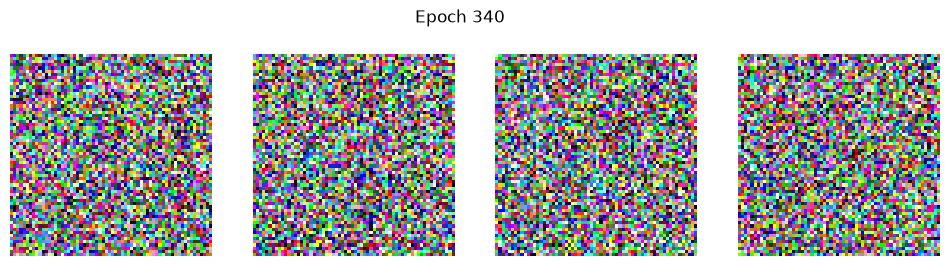

Epoch 340 average loss is 0.0305


Epoch 341/400: 100%|██████████| 172/172 [00:07<00:00, 22.37it/s, loss=0.0161] 


Epoch 341 average loss is 0.0321


Epoch 342/400: 100%|██████████| 172/172 [00:07<00:00, 22.47it/s, loss=0.0155] 


Epoch 342 average loss is 0.0317


...

Epoch 348/400: 100%|██████████| 172/172 [00:07<00:00, 22.54it/s, loss=0.0303] 


Epoch 348 average loss is 0.0314


Epoch 349/400: 100%|██████████| 172/172 [00:07<00:00, 22.14it/s, loss=0.0169] 


Epoch 349 average loss is 0.0294


Epoch 350/400: 100%|██████████| 172/172 [00:07<00:00, 22.41it/s, loss=0.0286] 


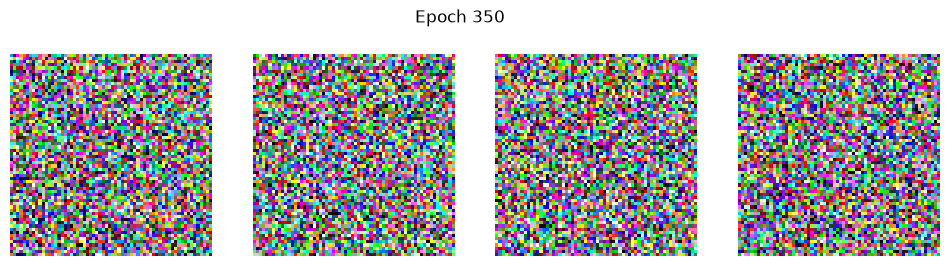

Epoch 350 average loss is 0.0297


Epoch 351/400: 100%|██████████| 172/172 [00:07<00:00, 22.56it/s, loss=0.00634]


Epoch 351 average loss is 0.0310


Epoch 352/400: 100%|██████████| 172/172 [00:07<00:00, 22.25it/s, loss=0.0323] 


Epoch 352 average loss is 0.0329


...

Epoch 358/400: 100%|██████████| 172/172 [00:07<00:00, 22.27it/s, loss=0.0139] 


Epoch 358 average loss is 0.0335


Epoch 359/400: 100%|██████████| 172/172 [00:07<00:00, 22.55it/s, loss=0.0133] 


Epoch 359 average loss is 0.0278


Epoch 360/400: 100%|██████████| 172/172 [00:07<00:00, 22.38it/s, loss=0.0282] 


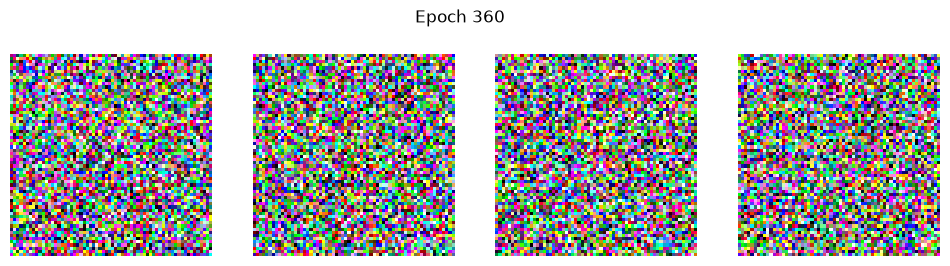

Epoch 360 average loss is 0.0297


Epoch 361/400: 100%|██████████| 172/172 [00:07<00:00, 22.46it/s, loss=0.00603]


Epoch 361 average loss is 0.0297


Epoch 362/400: 100%|██████████| 172/172 [00:07<00:00, 22.15it/s, loss=0.00997]


Epoch 362 average loss is 0.0305


...

Epoch 368/400: 100%|██████████| 172/172 [00:07<00:00, 22.72it/s, loss=0.0185] 


Epoch 368 average loss is 0.0297


Epoch 369/400: 100%|██████████| 172/172 [00:07<00:00, 22.01it/s, loss=0.0265] 


Epoch 369 average loss is 0.0288


Epoch 370/400: 100%|██████████| 172/172 [00:07<00:00, 22.58it/s, loss=0.074]  


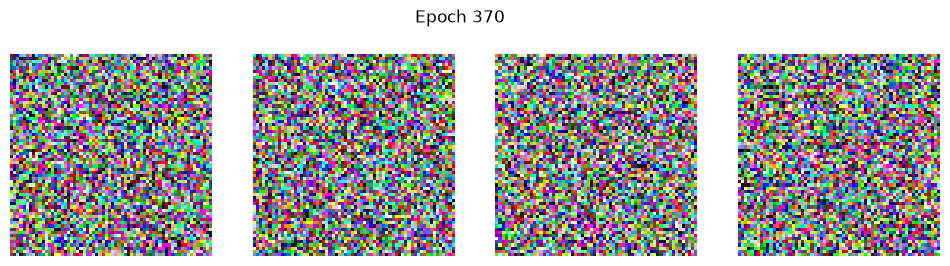

Epoch 370 average loss is 0.0301


Epoch 371/400: 100%|██████████| 172/172 [00:07<00:00, 22.75it/s, loss=0.0114] 


Epoch 371 average loss is 0.0286


Epoch 372/400: 100%|██████████| 172/172 [00:07<00:00, 22.40it/s, loss=0.0715] 


Epoch 372 average loss is 0.0302


...

Epoch 378/400: 100%|██████████| 172/172 [00:07<00:00, 22.33it/s, loss=0.0146] 


Epoch 378 average loss is 0.0332


Epoch 379/400: 100%|██████████| 172/172 [00:07<00:00, 22.72it/s, loss=0.012]  


Epoch 379 average loss is 0.0303


Epoch 380/400: 100%|██████████| 172/172 [00:07<00:00, 22.69it/s, loss=0.0376] 


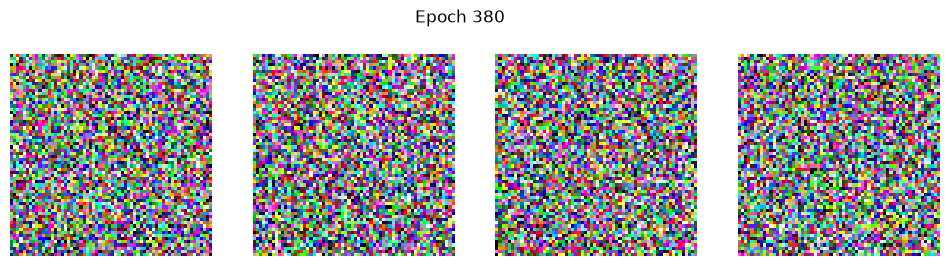

Epoch 380 average loss is 0.0321


Epoch 381/400: 100%|██████████| 172/172 [00:07<00:00, 22.39it/s, loss=0.0555] 


Epoch 381 average loss is 0.0325


Epoch 382/400: 100%|██████████| 172/172 [00:07<00:00, 22.63it/s, loss=0.0344] 


Epoch 382 average loss is 0.0306


...

Epoch 388/400: 100%|██████████| 172/172 [00:07<00:00, 22.68it/s, loss=0.00262]


Epoch 388 average loss is 0.0302


Epoch 389/400: 100%|██████████| 172/172 [00:07<00:00, 22.46it/s, loss=0.0911] 


Epoch 389 average loss is 0.0344


Epoch 390/400: 100%|██████████| 172/172 [00:07<00:00, 22.55it/s, loss=0.058]  


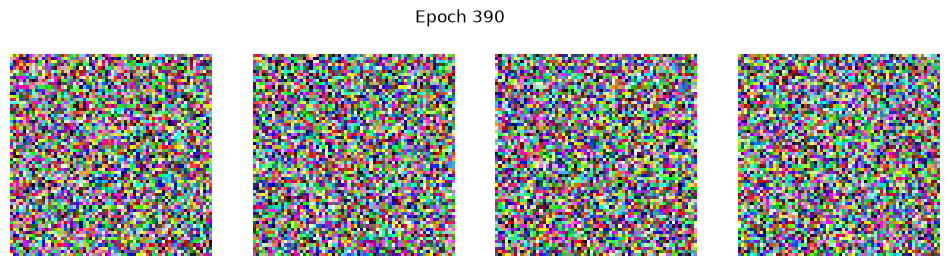

Epoch 390 average loss is 0.0302


Epoch 391/400: 100%|██████████| 172/172 [00:07<00:00, 22.63it/s, loss=0.0219] 


Epoch 391 average loss is 0.0296


Epoch 392/400: 100%|██████████| 172/172 [00:07<00:00, 22.39it/s, loss=0.033]  


Epoch 392 average loss is 0.0311


...

Epoch 398/400: 100%|██████████| 172/172 [00:07<00:00, 22.43it/s, loss=0.0406] 


Epoch 398 average loss is 0.0306


Epoch 399/400: 100%|██████████| 172/172 [00:07<00:00, 22.29it/s, loss=0.00584]


Epoch 399 average loss is 0.0326


Epoch 400/400: 100%|██████████| 172/172 [00:07<00:00, 22.41it/s, loss=0.00977]


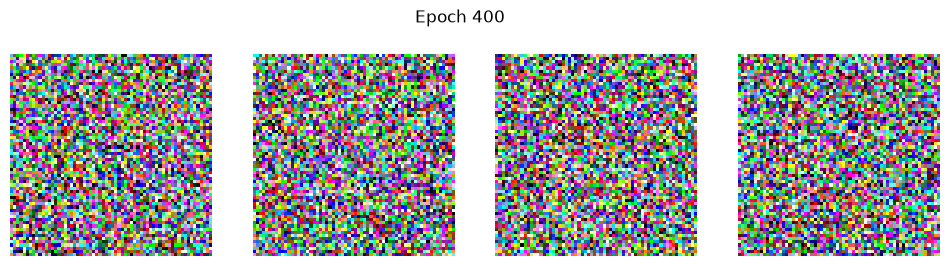

Epoch 400 average loss is 0.0312


In [24]:
for epoch in range(epochs):
    epoch_loss = 0.0
    progress = tqdm(dataloader, desc=f'Epoch {epoch+1}/{epochs}')

    for captions, images in progress:
        images = images.to(device)
        batch_size_actual = images.shape[0]

        t = torch.randint(0, timesteps, (batch_size_actual,), device=device)
        x_t, noise = schedule.add_noise(images, t)
        predicted_noise = model(x_t, t)

        loss = loss_fn(predicted_noise, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        progress.set_postfix(loss=loss.item())

    if (epoch + 1) % 10 == 0:
        samples = sample(model, schedule, batch_size=4, device=device)
        samples_display = (samples.clamp(-1, 1) + 1) / 2
        fig, axes = plt.subplots(1, 4, figsize=(12, 3))
        for i in range(4):
            axes[i].imshow(samples_display[i].permute(1, 2, 0).cpu().numpy())
            axes[i].axis("off")
        plt.suptitle(f"Epoch {epoch+1}")
        plt.show()

    avg_loss = epoch_loss / len(dataloader)
    print(f'Epoch {epoch+1} average loss is {avg_loss:.4f}')

    torch.save(model.state_dict(), 'unet_checkpoint.pt')

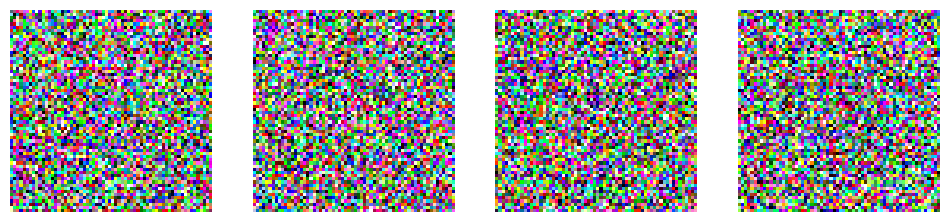

In [11]:
samples = sample(model, schedule, image_size=64, batch_size=4, channels=3, device=device)
samples = (samples.clamp(-1, 1) + 1) / 2  # back to [0, 1] for display

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):
    img = samples[i].permute(1, 2, 0).cpu().numpy()
    axes[i].imshow(img)
    axes[i].axis("off")
plt.show()